<a href="https://colab.research.google.com/github/Z4nata/CalculoNumerico/blob/main/atividade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática III

**Alunos:**

Felipe Zanata - 176287
Gabriel Padilha - 176297
Nicolas Elias - 178196

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

TOL = 1e-6
MAX_ITER = 100
EPS_ZERO = 1e-12

PROBLEMAS = {
    "f1": {"texto": "x² − 2",      "f": lambda x: x**2 - 2,        "df": lambda x: 2*x,
           "bissecao": (1, 2),   "newton": 1.5, "secante": (1, 2)},
    "f2": {"texto": "x³ − x − 2",  "f": lambda x: x**3 - x - 2,    "df": lambda x: 3*x**2 - 1,
           "bissecao": (1, 2),   "newton": 1.5, "secante": (1, 2)},
    "f3": {"texto": "e^(−x) − x",  "f": lambda x: np.exp(-x) - x,  "df": lambda x: -np.exp(-x) - 1,
           "bissecao": (0, 1),   "newton": 0.5, "secante": (0, 1)},
    "f4": {"texto": "x³ − 2x + 2", "f": lambda x: x**3 - 2*x + 2,  "df": lambda x: 3*x**2 - 2,
           "bissecao": (-2, -1), "newton": -2,  "secante": (-2, -1)},
}

## Parte 1 — Implementação dos métodos

**Critério de parada:** $|x_{k+1}-x_k| < \text{tol}$ **e** $|f(x_{k+1})| < \text{tol}$. Na bisseção, $|x_{k+1}-x_k|$ é substituído por $(b-a)/2$.

In [ ]:
def _resultado(metodo, raiz, iteracoes, aproximacoes, convergiu, mensagem, historico, f):
    return {"metodo": metodo, "raiz": raiz, "iteracoes": iteracoes,
            "aproximacoes": aproximacoes, "convergiu": convergiu, "mensagem": mensagem,
            "residuo": abs(f(raiz)) if raiz is not None else None, "historico": historico}


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return _resultado("Bisseção", None, 0, [], False, "f(a)·f(b) > 0", [], f)
    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        aproximacoes.append(c)
        historico.append({"a": a, "b": b, "c": c})
        if fc == 0 or ((b - a) / 2 < tol and abs(fc) < tol):
            return _resultado("Bisseção", c, k, aproximacoes, True, "convergiu", historico, f)
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return _resultado("Bisseção", c, max_iter, aproximacoes, False,
                      f"não convergiu em {max_iter} iterações", historico, f)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    x = x0
    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < EPS_ZERO:
            return _resultado("Newton", x, k - 1, aproximacoes, False,
                              f"f'(x) ≈ 0 em x = {x:.6g}", historico, f)
        x_novo = x - fx / dfx
        aproximacoes.append(x_novo)
        historico.append({"x": x, "fx": fx, "dfx": dfx, "x_novo": x_novo})
        if f(x_novo) == 0 or (abs(x_novo - x) < tol and abs(f(x_novo)) < tol):
            return _resultado("Newton", x_novo, k, aproximacoes, True, "convergiu", historico, f)
        x = x_novo
    return _resultado("Newton", x, max_iter, aproximacoes, False,
                      f"não convergiu em {max_iter} iterações", historico, f)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    aproximacoes, historico = [], []
    for k in range(1, max_iter + 1):
        f0, f1 = f(x0), f(x1)
        if abs(f1 - f0) < EPS_ZERO:
            return _resultado("Secante", x1, k - 1, aproximacoes, False,
                              "denominador ≈ 0", historico, f)
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        aproximacoes.append(x2)
        historico.append({"x0": x0, "x1": x1, "f0": f0, "f1": f1, "x2": x2})
        if f(x2) == 0 or (abs(x2 - x1) < tol and abs(f(x2)) < tol):
            return _resultado("Secante", x2, k, aproximacoes, True, "convergiu", historico, f)
        x0, x1 = x1, x2
    return _resultado("Secante", x1, max_iter, aproximacoes, False,
                      f"não convergiu em {max_iter} iterações", historico, f)

In [ ]:
f1, df1 = PROBLEMAS["f1"]["f"], PROBLEMAS["f1"]["df"]
f4, df4 = PROBLEMAS["f4"]["f"], PROBLEMAS["f4"]["df"]
for descricao, res in [("f(a)f(b) > 0",           bissecao(f1, 2, 3)),
                       ("f'(x0) = 0",             newton(f1, df1, 0)),
                       ("denominador nulo",       secante(f1, -1, 1)),
                       ("máximo de iterações",    newton(f4, df4, 0))]:
    print(f"{descricao:<22} convergiu = {res['convergiu']!s:<5}  {res['mensagem']}")

f(a)f(b) > 0           convergiu = False  f(a)·f(b) > 0
f'(x0) = 0             convergiu = False  f'(x) ≈ 0 em x = 0
denominador nulo       convergiu = False  denominador ≈ 0
máximo de iterações    convergiu = False  não convergiu em 100 iterações


## Parte 2 — Tabela de resultados

In [ ]:
def rodar_todos(problemas, tol=TOL, max_iter=MAX_ITER):
    linhas, resultados = [], {}
    for nome, p in problemas.items():
        f, df = p["f"], p["df"]
        a, b = p["bissecao"]; x0 = p["newton"]; s0, s1 = p["secante"]
        for res, iniciais in [(bissecao(f, a, b, tol, max_iter), f"[{a}, {b}]"),
                              (newton(f, df, x0, tol, max_iter), f"x0 = {x0}"),
                              (secante(f, s0, s1, tol, max_iter), f"({s0}, {s1})")]:
            resultados[(nome, res["metodo"])] = res
            linhas.append({
                "Função": f"{nome}(x) = {p['texto']}",
                "Método": res["metodo"],
                "Valores iniciais": iniciais,
                "Raiz aproximada": f"{res['raiz']:.8f}" if res["raiz"] is not None else "—",
                "|f(x)| final": f"{res['residuo']:.2e}" if res["residuo"] is not None else "—",
                "Iterações/resultado": (f"{res['iteracoes']} (convergiu)" if res["convergiu"]
                                        else f"falhou: {res['mensagem']}"),
            })
    return pd.DataFrame(linhas), resultados

tabela, resultados = rodar_todos(PROBLEMAS)
tabela.to_csv("tabela_resultados.csv", index=False)
tabela

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[1, 2]",1.41421366,2.69e-07,21 (convergiu)
1,f1(x) = x² − 2,Newton,x0 = 1.5,1.41421356,4.44e-16,4 (convergiu)
2,f1(x) = x² − 2,Secante,"(1, 2)",1.41421356,8.88e-16,6 (convergiu)
3,f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.52137971,1.45e-08,22 (convergiu)
4,f2(x) = x³ − x − 2,Newton,x0 = 1.5,1.52137971,4.53e-14,3 (convergiu)
5,f2(x) = x³ − x − 2,Secante,"(1, 2)",1.52137971,1.84e-14,7 (convergiu)
6,f3(x) = e^(−x) − x,Bisseção,"[0, 1]",0.56714344,2.35e-07,20 (convergiu)
7,f3(x) = e^(−x) − x,Newton,x0 = 0.5,0.56714329,4.44e-15,3 (convergiu)
8,f3(x) = e^(−x) − x,Secante,"(0, 1)",0.56714329,1.24e-13,5 (convergiu)
9,f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.76929235,2.55e-09,21 (convergiu)


## Parte 3 — Animações

In [ ]:
def animar(res, f, titulo, arquivo, xlim, ylim, fps=1.2, max_quadros=12):
    hist = res["historico"][:max_quadros]
    x_graf = np.linspace(*xlim, 500)
    fig, ax = plt.subplots(figsize=(7, 4.6))

    def atualizar(k):
        ax.clear()
        ax.plot(x_graf, f(x_graf), color="tab:blue", lw=2, label="f(x)")
        ax.axhline(0, color="k", lw=0.9)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.grid(alpha=0.3)
        h = hist[k]
        if res["metodo"] == "Bisseção":
            a, b, c = h["a"], h["b"], h["c"]
            ax.axvspan(a, b, color="orange", alpha=0.25, label="intervalo [a, b]")
            ax.plot([a, b], [f(a), f(b)], "o", color="darkorange")
            ax.vlines([a, b], 0, [f(a), f(b)], colors="darkorange", ls=":")
            ax.plot(c, f(c), "o", color="red", ms=8, label="c = (a+b)/2")
            ax.vlines(c, 0, f(c), colors="red", ls="--")
            atual, extra = c, f"[a, b] = [{a:.6f}, {b:.6f}]   largura = {b-a:.2e}"
        elif res["metodo"] == "Newton":
            for hp in hist[:k]:
                ax.plot(hp["x"], hp["fx"], "o", color="gray", ms=4)
            x, fx, dfx, xn = h["x"], h["fx"], h["dfx"], h["x_novo"]
            ax.plot(x_graf, fx + dfx * (x_graf - x), color="green", lw=1.3, label=r"tangente em $x_k$")
            ax.plot(x, fx, "o", color="black", ms=7)
            ax.vlines(x, 0, fx, colors="black", ls=":")
            ax.plot(xn, 0, "o", color="red", ms=8, label=r"$x_{k+1}$")
            atual, extra = xn, f"x_k = {x:.6f}   f'(x_k) = {dfx:.4f}"
        else:
            for hp in hist[:k]:
                ax.plot(hp["x1"], hp["f1"], "o", color="gray", ms=4)
            x0, x1, f0, f1, x2 = h["x0"], h["x1"], h["f0"], h["f1"], h["x2"]
            incl = (f1 - f0) / (x1 - x0)
            ax.plot(x_graf, f1 + incl * (x_graf - x1), color="purple", lw=1.3,
                    label=r"secante por $x_{k-1}, x_k$")
            ax.plot([x0, x1], [f0, f1], "o", color="black", ms=7)
            ax.plot(x2, 0, "o", color="red", ms=8, label=r"$x_{k+1}$")
            atual, extra = x2, f"x_(k−1) = {x0:.6f}   x_k = {x1:.6f}"
        ax.set_title(f"{res['metodo']} — {titulo}", fontsize=12)
        ax.text(0.02, 0.97, f"iteração k = {k+1}\naproximação = {atual:.8f}\n"
                f"resíduo |f| = {abs(f(atual)):.2e}\n{extra}",
                transform=ax.transAxes, va="top", fontsize=9, family="monospace",
                bbox=dict(fc="white", ec="gray", alpha=0.9))
        ax.legend(loc="upper right", fontsize=8)

    anim = FuncAnimation(fig, atualizar, frames=len(hist), interval=1000 / fps)
    anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return arquivo

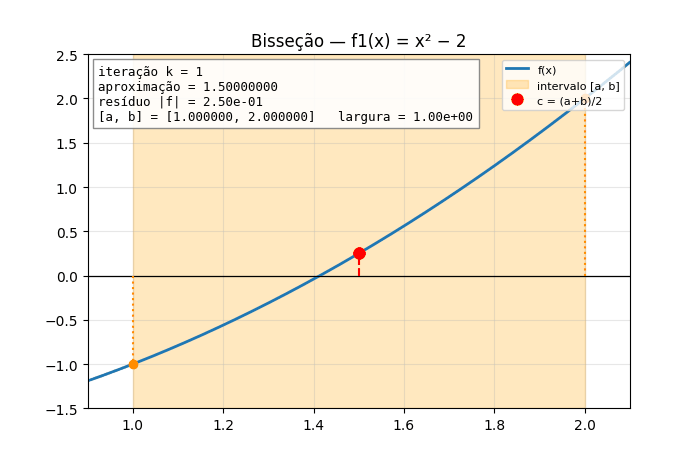

In [ ]:
display(Image(filename=animar(resultados[("f1", "Bisseção")], PROBLEMAS["f1"]["f"],
        "f1(x) = x² − 2", "bissecao_f1.gif", xlim=(0.9, 2.1), ylim=(-1.5, 2.5))))

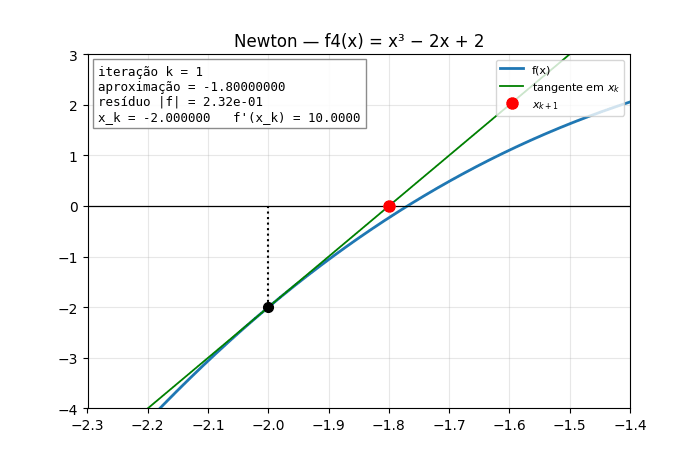

In [ ]:
display(Image(filename=animar(resultados[("f4", "Newton")], PROBLEMAS["f4"]["f"],
        "f4(x) = x³ − 2x + 2", "newton_f4.gif", xlim=(-2.3, -1.4), ylim=(-4, 3))))

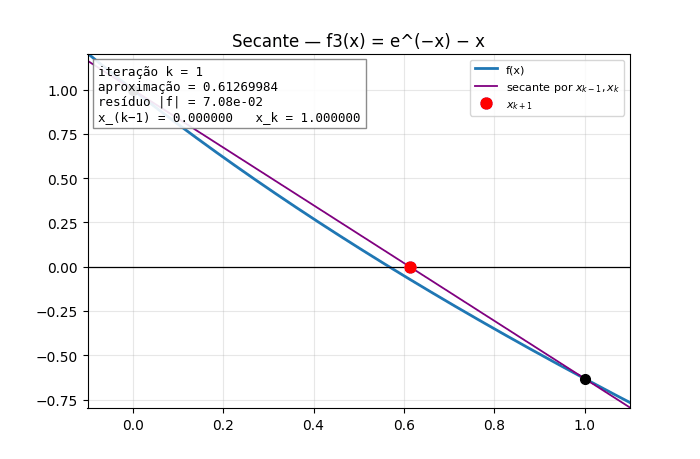

In [ ]:
display(Image(filename=animar(resultados[("f3", "Secante")], PROBLEMAS["f3"]["f"],
        "f3(x) = e^(−x) − x", "secante_f3.gif", xlim=(-0.1, 1.1), ylim=(-0.8, 1.2))))